# Introduction

This dataset, Student Exam Scores, contains information about students’ performance in different subjects. The goal of this analysis is to explore how various factors — such as study hours, preparation level, and individual effort — affect exam results.

By analyzing this dataset, we aim to:

Understand the overall performance trends of students.

Identify correlations between study-related factors and exam scores.

Visualize patterns to gain insights into student learning outcomes.

This analysis will help in recognizing key factors that contribute to better exam performance and can be useful for teachers, students, and educational institutions to improve academic strategies.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import warnings 
warnings.filterwarnings("ignore")

In [2]:
std = pd.read_csv("/kaggle/input/student-exam-scores-analysis-ipyn/student_exam_scores.csv")
std

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


# EDA Form Dataset

In [3]:
std.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [4]:
std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [5]:
std.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [6]:
std.shape

(200, 6)

In [7]:
std.dropna()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [8]:
var = pd.DataFrame({
    "Column Name": std.columns,
    "Data Type": std.dtypes.values
})
var

,Column Name,Data Type
0,student_id,object
1,hours_studied,float64
2,sleep_hours,float64
3,attendance_percent,float64
4,previous_scores,int64
5,exam_score,float64


In [9]:
std.duplicated().sum()

0

In [10]:
std.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

# Subplot In Dataset

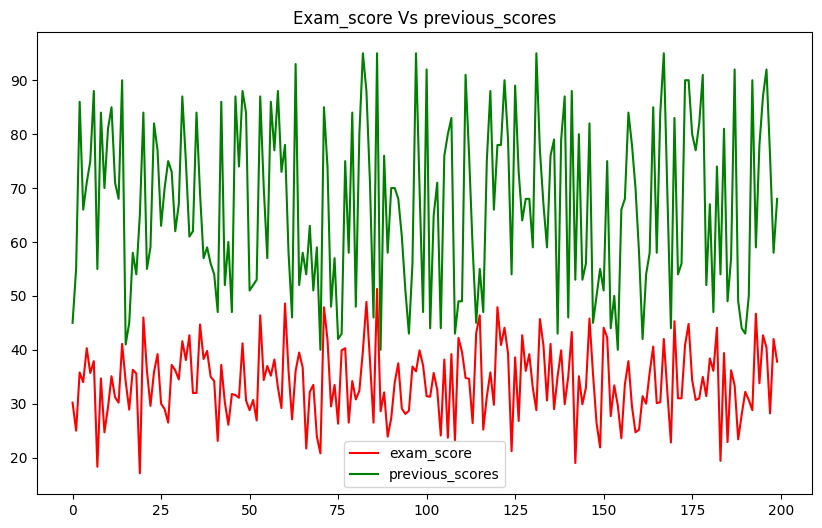

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(std.index, std['exam_score'], color='red', label='exam_score')
ax.plot(std.index, std['previous_scores'], color='green', label='previous_scores')

ax.set_title("Exam_score Vs previous_scores")
ax.legend()

plt.show()

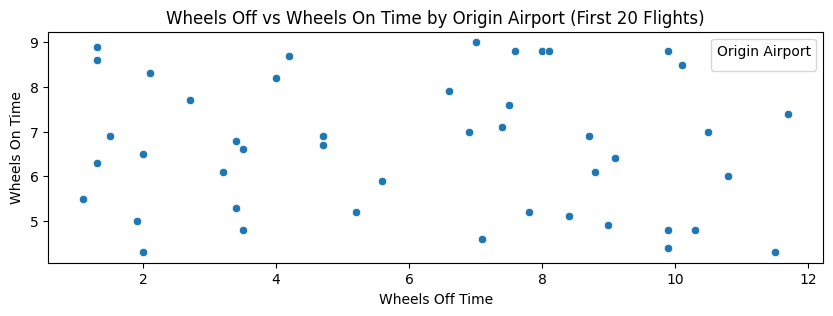

In [12]:
plt.figure(figsize=(10,3))
sns.scatterplot(
    data=std.head(45),   # show just first 20 rows
    x='hours_studied',
    y='sleep_hours',
    #hue='origin'
)
plt.title("Wheels Off vs Wheels On Time by Origin Airport (First 20 Flights)")
plt.xlabel("Wheels Off Time")
plt.ylabel("Wheels On Time")
plt.legend(title='Origin Airport')
plt.show()

# KDE Plot In Dataset

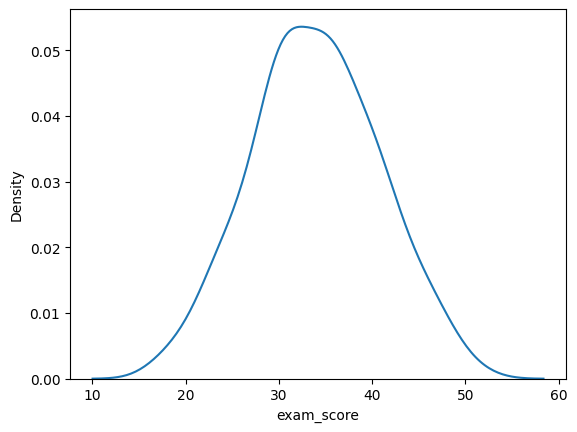

In [13]:
# kdeplot in dataset display columns result exam
sns.kdeplot(std["exam_score"])
plt.show()

# Scatter Plot In Dataset

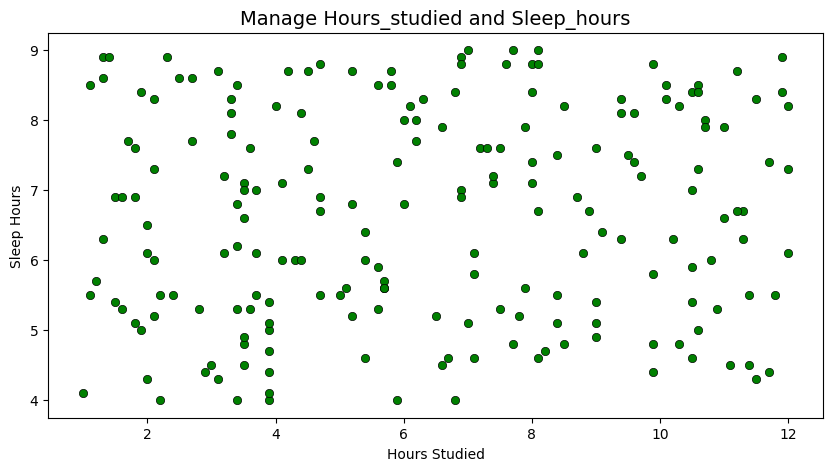

In [14]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=std,
    x='hours_studied', 
    y='sleep_hours',
    color='green',      
    edgecolor='black'    
)
plt.title("Manage Hours_studied and Sleep_hours", fontsize=14)
plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.show()


# Sub Plot In Dataset

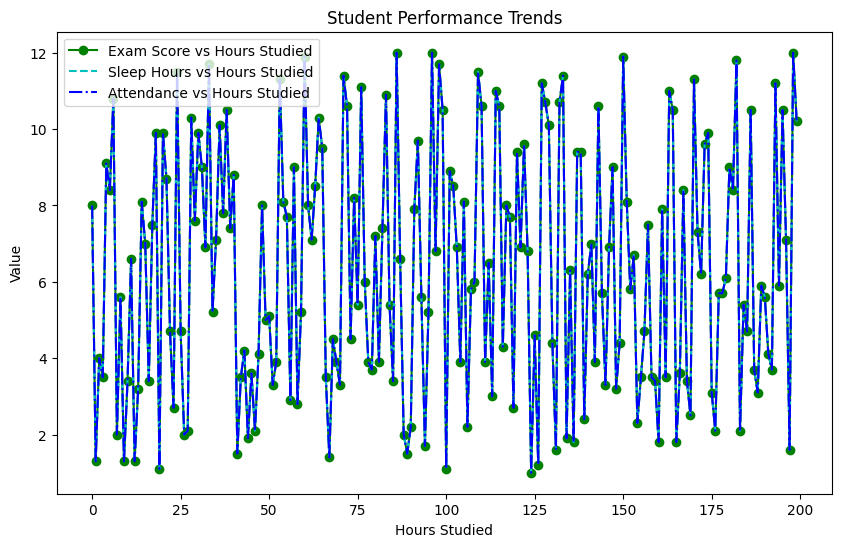

In [15]:
fig, axes = plt.subplots(figsize=(10, 6))
data = std.head(5)


axes.plot(std['hours_studied'], '-og', label='Exam Score vs Hours Studied')
axes.plot(std['hours_studied'], '--c', label='Sleep Hours vs Hours Studied')
axes.plot(std['hours_studied'], '-.b', label='Attendance vs Hours Studied')

axes.set_title("Student Performance Trends")
axes.set_xlabel("Hours Studied")
axes.set_ylabel("Value")
axes.legend()
plt.show()


# Line Plot In The Dataset

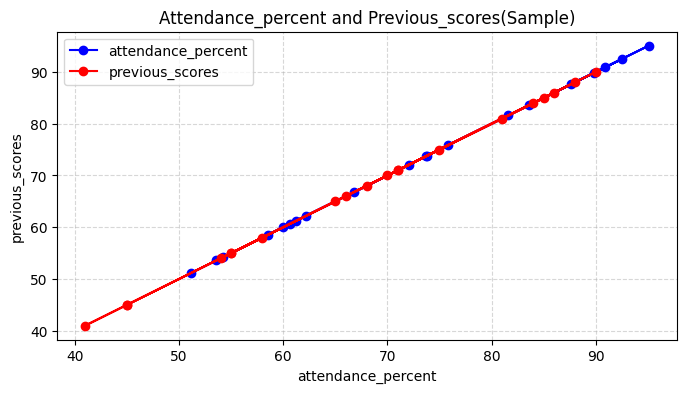

In [16]:
plt.figure(figsize=(8,4))
sample = std.head(20)  # display just first 100 rows
plt.plot(sample['attendance_percent'], sample['attendance_percent'], 'bo-', label='attendance_percent')
plt.plot(sample['previous_scores'], sample['previous_scores'], 'ro-', label='previous_scores')
plt.title("Attendance_percent and Previous_scores(Sample)")
plt.xlabel("attendance_percent")
plt.ylabel("previous_scores")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Violin Plot In The Dataset

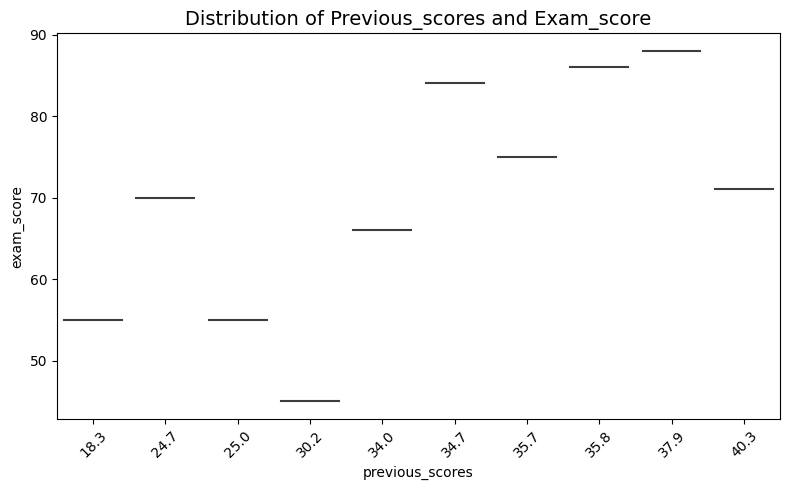

In [17]:
plt.figure(figsize=(8,5))
sns.violinplot(data=std.head(10),
               x="exam_score",
               y="previous_scores",
               inner="quartile", 
               scale="width"
              )

plt.title("Distribution of Previous_scores and Exam_score", fontsize=14)
plt.xticks(rotation=45)
plt.ylabel("exam_score")
plt.xlabel("previous_scores")
plt.tight_layout()
plt.show()

# Histogram From Dataset

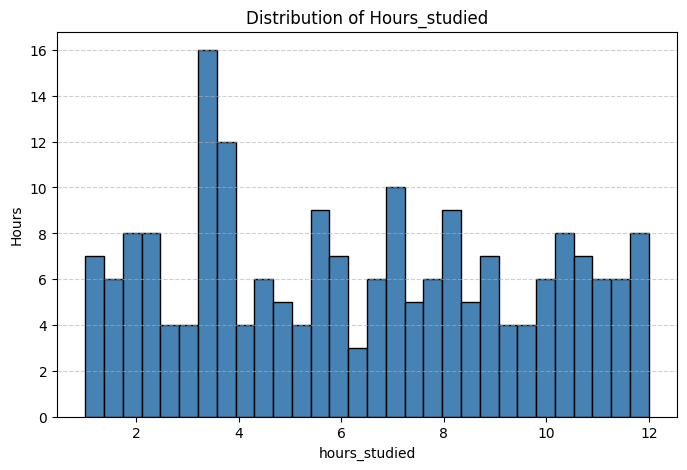

In [18]:
plt.figure(figsize=(8,5))
plt.hist(std["hours_studied"], bins=30, color='steelblue', edgecolor='black')

plt.title("Distribution of Hours_studied")
plt.xlabel("hours_studied")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Heatmap From The Dataset

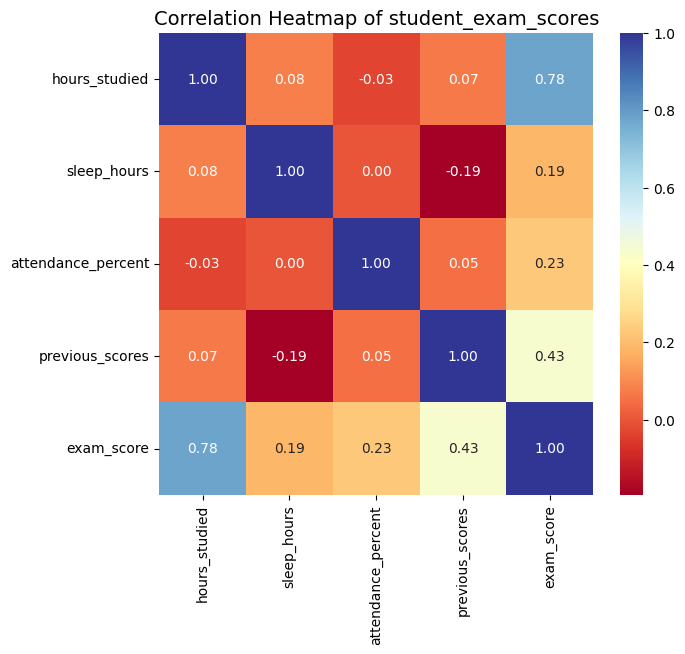

In [19]:
corr = std[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', "exam_score"]].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="RdYlBu", fmt=".2f")
plt.title("Correlation Heatmap of student_exam_scores", fontsize=14)
#plt.tight_layout()
plt.show()

# Conculsion

Students who study more, sleep well, and attend classes regularly tend to score higher in exams.
The analysis shows clear links between study habits and academic performance.

# 😊 Thank you for checking out my notebook!